# Projekt 01 (basic) — Netzwerkverkehr klassifizieren: von Flows zu Features

> **Modul 15 — ML for Networks** · Format: **Jupyter Notebook**
>
> **Warum dieses Format?** Hier geht es um **Datenverständnis**: echte, schmutzige
> Netzwerkdaten anschauen, Features bauen, Verteilungen plotten, Modelle vergleichen. Genau der
> explorative Ablauf, für den ein Notebook gemacht ist (wie in Modul 02–04).

## Ziel
Du arbeitest zum ersten Mal mit **echten Flow-Daten** (KDD Cup 99, via `scikit-learn`) und:
1. verstehst die **Feature-Struktur** eines Flow-Records (Volumen, Zeit, Protokoll, Kontext),
2. baust eine saubere **Vorverarbeitung** (Typen casten, kategoriale Features kodieren,
   schwere Ränder **log-transformieren**),
3. klassifizierst **normal vs. Angriff** und **die Angriffstypen** (13 Klassen),
4. läufst in die **Accuracy-Falle** — und verstehst, warum 99,9 % nichts bedeuten.

## Vorwissen
Skript Modul 15, Abschnitte **1** (Flows, Features) und **3.1 Stufe 1** (Accuracy-Falle).
Modul 04 (Klassifikation, Pipelines, Metriken), pandas.

## Was am Ende funktionieren soll
Ein Random Forest mit ~99,99 % Accuracy — und deine Erkenntnis, dass der triviale Klassifikator
„alles ist normal" schon **96,6 %** schafft, die tollen Zahlen also fast nichts aussagen.

> **Datensatz-Warnung (wichtig, siehe Skript 3.6):** KDD Cup 99 ist **veraltet (1999),
> synthetisch, redundant und zu leicht**. Wir nutzen es, weil es ohne Download-Hürde echte
> Flow-Features mit realistischem Ungleichgewicht liefert — ideal, um **Methodik** zu lernen.
> Es erlaubt **keine** Aussage über reale IDS-Güte. Für echte Arbeit: UNSW-NB15 / CIC-IDS2017.

> **Arbeitsweise:** `# TODO`-Stellen selbst füllen. Lösung: `loesung/flow_klassifikation_loesung.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

RANDOM_STATE = 0
pd.set_option("display.width", 120)
print("pandas", pd.__version__)

pandas 2.3.3


## 1 · Die Daten laden

`fetch_kddcup99` lädt beim ersten Aufruf ~2 MB herunter (danach gecached in
`~/scikit_learn_data`). Wir nehmen den Teildatensatz **`SA`** (10 %-Variante): ~100 000 Flows mit
**96,6 % Normalverkehr** — ein realistisches Ungleichgewicht.

Jede Zeile ist ein **Flow** (eine Verbindung) mit 41 Features. Die Spalten sind genau die aus
Skript 1.3: Volumen (`src_bytes`, `dst_bytes`), Zeit (`duration`), Protokoll (`protocol_type`,
`service`, `flag`) und **Kontext** (`count`, `srv_count`, … = Verbindungen im Zeitfenster).

In [2]:
data = fetch_kddcup99(subset="SA", percent10=True, as_frame=True, random_state=RANDOM_STATE)
df = data.frame.copy()
print("Rohform:", df.shape)
df.head(3)

Rohform: (100655, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'


## 2 · Aufräumen — die erste Realitätsdusche

Zwei typische Eigenheiten echter Daten:
1. **Alle Spalten sind `object`** (auch die Zahlen!) → müssen gecastet werden.
2. Die Werte sind **Bytes**: `b'normal.'` statt `normal`.

> ⚠️ **Eine Falle, in die fast jeder tappt.** Es ist verlockend, die Bytes so zu putzen:
> ```python
> s.astype(str).str.strip("b'")        # FALSCH!
> ```
> `str.strip` entfernt **alle** Zeichen aus der Menge `{b, '}` von beiden Enden — nicht das
> Präfix `b'`. Aus `b'back.'` wird damit **`ack`** (das „b" von *back* wird mitgefressen!), und
> der Dienst `b'bgp'` wird zu `gp`. Man zerstört still und leise Daten und merkt es nie.
> **Richtig** ist ein echtes `decode()` — so machen wir es unten.

In [3]:
def bytes_zu_str(spalte):
    # Bytes sauber dekodieren (NICHT mit str.strip("b'") - siehe Warnung oben!)
    return spalte.apply(lambda v: v.decode() if isinstance(v, bytes) else str(v))

# Labels: b'normal.' -> normal   (nur den abschliessenden Punkt entfernen)
df["labels"] = bytes_zu_str(df["labels"]).str.rstrip(".")

# kategoriale vs. numerische Spalten trennen
KATEGORIAL = ["protocol_type", "service", "flag"]
numerisch = [c for c in df.columns if c not in KATEGORIAL + ["labels"]]

for c in KATEGORIAL:
    df[c] = bytes_zu_str(df[c])
for c in numerisch:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Gegenprobe, dass nichts zerstoert wurde:
assert "back" in set(df["labels"]), "Label 'back' kaputt -> str.strip-Falle!"
print("Klassen:", df['labels'].nunique())
print(df["labels"].value_counts())
print("\nNormalanteil: %.2f %%" % (100 * (df["labels"] == "normal").mean()))
print("Dienste (Auszug):", sorted(df['service'].unique())[:12])

Klassen: 13
labels
normal         97278
smurf           2357
neptune          928
back              24
satan             15
ipsweep           14
portsweep         14
teardrop          11
warezclient        9
nmap               2
pod                1
multihop           1
warezmaster        1
Name: count, dtype: int64

Normalanteil: 96.64 %
Dienste (Auszug): ['IRC', 'X11', 'Z39_50', 'auth', 'courier', 'csnet_ns', 'domain', 'domain_u', 'eco_i', 'ecr_i', 'efs', 'finger']


## 3 · Die Daten anschauen (EDA)

**Deine Aufgabe:** Schau dir die **Verteilung von `src_bytes`** an. Netzwerkverkehr hat
**schwere Ränder** (Skript 1.4): wenige Elefanten-Flows, Millionen Mäuse. Plotte ein Histogramm
von `src_bytes` — einmal roh, einmal **log-transformiert** ($\log(1+x)$).

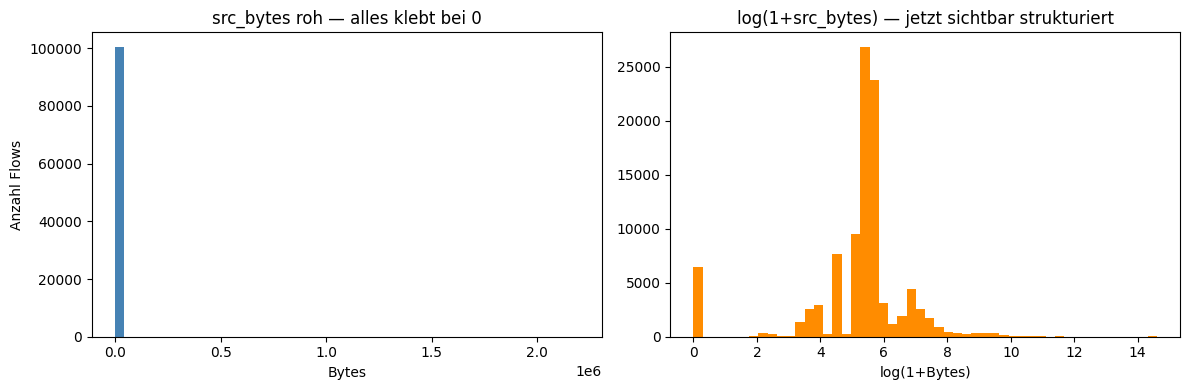

Spannweite src_bytes: 0 bis 2194619
Median: 232.0 | Mittelwert: 1153.1
-> Mittelwert >> Median: klassischer schwerer Rand (heavy tail).


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df["src_bytes"], bins=50, color="steelblue")
ax1.set(title="src_bytes roh — alles klebt bei 0", xlabel="Bytes", ylabel="Anzahl Flows")
ax2.hist(np.log1p(df["src_bytes"]), bins=50, color="darkorange")
ax2.set(title="log(1+src_bytes) — jetzt sichtbar strukturiert", xlabel="log(1+Bytes)")
plt.tight_layout(); plt.show()

print("Spannweite src_bytes:", df["src_bytes"].min(), "bis", df["src_bytes"].max())
print("Median:", df["src_bytes"].median(), "| Mittelwert:", round(df["src_bytes"].mean(), 1))
print("-> Mittelwert >> Median: klassischer schwerer Rand (heavy tail).")

## 4 · Features bauen

**Deine Aufgabe:** Baue die Design-Matrix `X` und das binäre Ziel `y`:
- `y = 1`, wenn `labels != "normal"` (Angriff), sonst 0.
- `X`: alle Spalten außer `labels`; die **kategorialen** (`protocol_type`, `service`, `flag`) per
  **One-Hot** (`pd.get_dummies`) kodieren; die Byte-Zähler **log-transformieren**.

> **Warum log?** Siehe Plot oben: `src_bytes` reicht von 0 bis ~10⁹. Ohne Log dominiert ein
> einzelner Elefanten-Flow jede Distanz-/Gradienten-Rechnung. Bäume stört das wenig, lineare
> Modelle sehr.

In [5]:
LOG_SPALTEN = ["src_bytes", "dst_bytes", "duration"]

y = (df["labels"] != "normal").astype(int)

X = df.drop(columns=["labels"]).copy()
for c in LOG_SPALTEN:
    X[c] = np.log1p(X[c])
X = pd.get_dummies(X, columns=KATEGORIAL).astype(float)

print("X:", X.shape, "| Angriffsanteil: %.2f %%" % (100*y.mean()))
print("Durch One-Hot aus 41 Spalten geworden:", X.shape[1])

X: (100655, 94) | Angriffsanteil: 3.36 %
Durch One-Hot aus 41 Spalten geworden: 94


## 5 · Aufteilen und Modelle trainieren

> ⚠️ **Achtung — hier machen wir bewusst etwas Falsches:** Wir splitten **zufällig**. Bei
> Netzwerkdaten ist das **Leakage** (Skript 3.5), weil Flows desselben Angriffs in Train *und*
> Test landen. Für dieses Einstiegsprojekt ist das ok — merke dir aber: **die Zahlen unten sind
> deshalb zu optimistisch.** Projekt 03 macht es richtig.

Wir vergleichen drei Modelle:
- **DummyClassifier** (`strategy="most_frequent"`) — sagt immer „normal". Die **Messlatte**.
- **Logistische Regression** — linear, mit Skalierung.
- **Random Forest** — Ensemble aus Bäumen.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

modelle = {
    "Dummy (immer 'normal')": DummyClassifier(strategy="most_frequent"),
    "Logistische Regression": make_pipeline(StandardScaler(),
                                            LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                            random_state=RANDOM_STATE),
}

ergebnisse = {}
for name, m in modelle.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary",
                                                    zero_division=0)
    ergebnisse[name] = dict(Accuracy=acc, Precision=pr, Recall=rc, F1=f1)
    print(f"{name:24s} fertig.")

pd.DataFrame(ergebnisse).T.round(5)

Train: (70458, 94) | Test: (30197, 94)
Dummy (immer 'normal')   fertig.


Logistische Regression   fertig.


Random Forest            fertig.


,Accuracy,Precision,Recall,F1
Dummy (immer 'normal'),0.96645,0.00000,0.00000,0.00000
Logistische Regression,0.99957,0.99505,0.99210,0.99357
Random Forest,0.99987,1.00000,0.99605,0.99802


## 6 · Die Accuracy-Falle 🪤

Schau dir die Tabelle genau an. Der **Dummy**, der ausnahmslos „normal" sagt und **keinen
einzigen Angriff** findet, hat eine Accuracy von **96,6 %**.

Der Random Forest hat 99,99 % — das sind, gemessen an der Accuracy, nur **3 Prozentpunkte
besser** als „gar nichts tun". Die Accuracy **versteckt** den gesamten relevanten Unterschied,
weil sie von der 96,6-%-Mehrheitsklasse dominiert wird.

Precision/Recall/F1 zeigen die Wahrheit: Dummy = **0,0**, Random Forest ≈ **1,0**.

**Merksatz:** *Bei starkem Klassenungleichgewicht ist Accuracy keine Metrik, sondern eine
Täuschung.* — Und das hier ist erst **Stufe 1**. Stufe 2 (der **Base-Rate-Fallacy**) kommt in
Projekt 02 und ist deutlich unangenehmer.

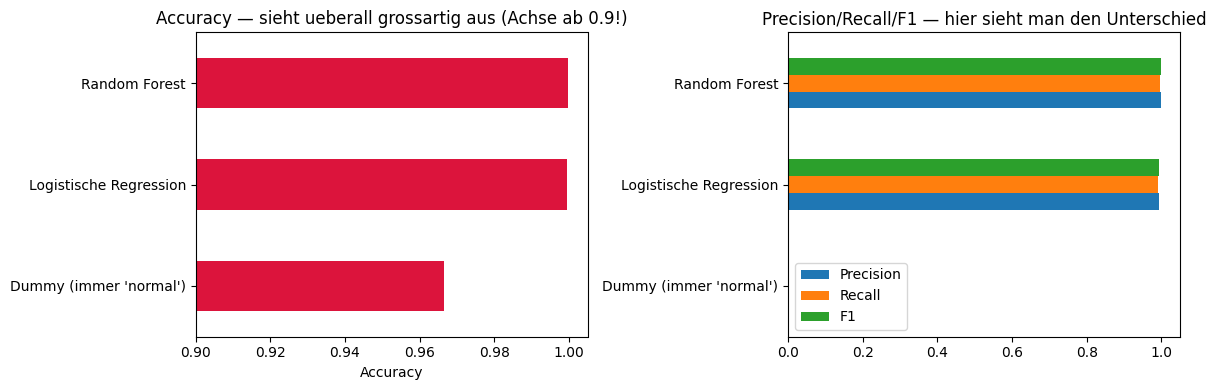

Dummy-Accuracy      : 0.96645
RandomForest-Accuracy: 0.99987
--> Differenz in Accuracy: 0.03341   ABER Recall: 0.0 vs. 0.996


In [7]:
df_erg = pd.DataFrame(ergebnisse).T
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df_erg["Accuracy"].plot.barh(ax=ax1, color="crimson", xlim=(0.9, 1.005))
ax1.set(title="Accuracy — sieht ueberall grossartig aus (Achse ab 0.9!)", xlabel="Accuracy")
df_erg[["Precision", "Recall", "F1"]].plot.barh(ax=ax2)
ax2.set(title="Precision/Recall/F1 — hier sieht man den Unterschied", xlim=(0, 1.05))
plt.tight_layout(); plt.show()

print("Dummy-Accuracy      :", round(ergebnisse["Dummy (immer 'normal')"]["Accuracy"], 5))
print("RandomForest-Accuracy:", round(ergebnisse["Random Forest"]["Accuracy"], 5))
print("--> Differenz in Accuracy:",
      round(ergebnisse["Random Forest"]["Accuracy"]-ergebnisse["Dummy (immer 'normal')"]["Accuracy"], 5),
      "  ABER Recall: 0.0 vs.",
      round(ergebnisse["Random Forest"]["Recall"], 3))

## 7 · Mehrklassen: welcher Angriff ist es?

Bis jetzt nur normal/Angriff. Jetzt die 13 echten Klassen — und dabei stolpern wir über ein
Problem, das **echte Daten ständig haben**:

Einige Angriffstypen kommen **genau einmal** im ganzen Datensatz vor (`multihop`, `pod`,
`warezmaster`). Ein *stratifizierter* Split ist damit **unmöglich** — man kann ein einzelnes
Beispiel nicht auf Train *und* Test aufteilen. `train_test_split(..., stratify=...)` wirft hier
einen `ValueError`.

**Das ist kein Bug, sondern die Realität:** Bei Angriffserkennung gibt es immer einen langen
Schwanz extrem seltener Klassen. Man hat drei Optionen:
1. die Ultra-Seltenen **entfernen** (machen wir hier — ehrlich dokumentiert),
2. sie zu einer Sammelklasse „sonstiger Angriff" **zusammenfassen**,
3. sie als **Anomalie**-Problem behandeln statt als Klassifikation (→ **Projekt 03**!).

> Wer nur Option 1 wählt und es nicht dazusagt, schönt seine Ergebnisse: Man wirft genau die
> schwierigen Fälle weg und berichtet dann hohe Zahlen.

In [8]:
# Wie selten sind die seltensten Klassen wirklich?
haeufigkeit = df["labels"].value_counts()
print("Die 6 seltensten Klassen:")
print(haeufigkeit.tail(6))

MIN_PRO_KLASSE = 10
behalten = haeufigkeit[haeufigkeit >= MIN_PRO_KLASSE].index
maske = df["labels"].isin(behalten)
print(f"\nEntfernt: {(~maske).sum()} Flows aus {df['labels'].nunique()-len(behalten)} "
      f"Ultra-Klassen (<{MIN_PRO_KLASSE} Beispiele) -> {len(behalten)} Klassen bleiben.")

X_m, y_multi = X[maske.values], df.loc[maske, "labels"]
Xtr, Xte, ytr_m, yte_m = train_test_split(X_m, y_multi, test_size=0.3, stratify=y_multi,
                                          random_state=RANDOM_STATE)
rf_multi = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_multi.fit(Xtr, ytr_m)
pred_m = rf_multi.predict(Xte)

print("\n" + classification_report(yte_m, pred_m, zero_division=0))
print("Lies die 'support'-Spalte: bei Klassen mit 3-5 Testbeispielen ist jede")
print("Prozentzahl reines Rauschen - eine Fehlklassifikation = -20 bis -33 Punkte.")

Die 6 seltensten Klassen:
labels
teardrop       11
warezclient     9
nmap            2
pod             1
multihop        1
warezmaster     1
Name: count, dtype: int64

Entfernt: 14 Flows aus 5 Ultra-Klassen (<10 Beispiele) -> 8 Klassen bleiben.



              precision    recall  f1-score   support

        back       1.00      1.00      1.00         7
     ipsweep       1.00      1.00      1.00         4
     neptune       1.00      1.00      1.00       279
      normal       1.00      1.00      1.00     29184
   portsweep       1.00      1.00      1.00         4
       satan       1.00      0.80      0.89         5
       smurf       1.00      1.00      1.00       707
    teardrop       1.00      0.67      0.80         3

    accuracy                           1.00     30193
   macro avg       1.00      0.93      0.96     30193
weighted avg       1.00      1.00      1.00     30193

Lies die 'support'-Spalte: bei Klassen mit 3-5 Testbeispielen ist jede
Prozentzahl reines Rauschen - eine Fehlklassifikation = -20 bis -33 Punkte.


## 8 · Welche Features zählen? (und warum das verdächtig ist)

Der Random Forest liefert `feature_importances_`. Schau dir die Top-10 an.

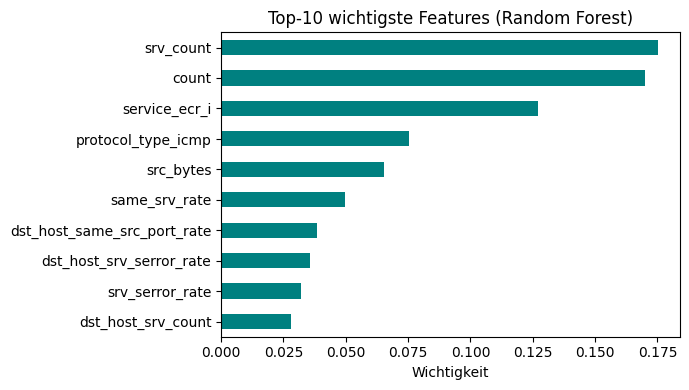

srv_count                      0.1753
count                          0.1702
service_ecr_i                  0.1269
protocol_type_icmp             0.0754
src_bytes                      0.0655
same_srv_rate                  0.0495
dst_host_same_src_port_rate    0.0383
dst_host_srv_serror_rate       0.0356
srv_serror_rate                0.0320
dst_host_srv_count             0.0282
dtype: float64


In [9]:
imp = pd.Series(rf_multi.feature_importances_, index=X.columns).nlargest(10)
plt.figure(figsize=(7, 4))
imp.sort_values().plot.barh(color="teal")
plt.title("Top-10 wichtigste Features (Random Forest)")
plt.xlabel("Wichtigkeit"); plt.tight_layout(); plt.show()
print(imp.round(4))

## 9 · Fazit

**Was du gelernt hast:**
1. **Flow-Daten sind echte, schmutzige Daten** — alle Spalten `object`, Labels als Bytes,
   kategoriale Features, extreme Wertebereiche.
2. **Schwere Ränder sind die Norm** (Mittelwert ≫ Median bei `src_bytes`) → **log-transformieren**.
3. **Die Accuracy-Falle**: Der Dummy erreicht 96,6 %, ohne irgendetwas zu können. Accuracy ist
   bei Ungleichgewicht wertlos — nutze **Precision/Recall**.
4. **Seltene Klassen** (`teardrop`: 11 Beispiele) lassen sich statistisch kaum bewerten.

**Und jetzt die unangenehme Wahrheit** (Skript 3.6): Die 99,99 % sind **zu gut, um wahr zu sein**.
Drei Gründe: (a) KDD99 ist **redundant und zu leicht** — Artefakte wie `src_bytes` trennen die
Klassen fast perfekt; (b) wir haben **zufällig gesplittet** → **Leakage**; (c) die Basisrate von
3,36 % Angriffen ist für ein reales Netz **absurd hoch**. In einem echten Netz sähe das völlig
anders aus — **warum genau**, rechnet **Projekt 02** durch.

### Mini-Aufgaben
1. Lass die Log-Transformation weg — was passiert mit der **logistischen Regression**
   (und warum kaum etwas mit dem Random Forest)?
2. Trainiere den RF nur auf `protocol_type`/`service`/`flag` (ohne Volumen-Features).
   Wie viel Accuracy bleibt?
3. Wirf `src_bytes` **raus** und trainiere neu. Sackt die Leistung ein? Was sagt das über
   die Qualität des Datensatzes?
4. Schau dir die **Konfusionsmatrix** (`confusion_matrix`) der Mehrklassen-Variante an: welche
   Angriffe werden verwechselt?